In [1]:
from velocileptors.EPT.moment_expansion_fftw import MomentExpansion
import os
import sys
sys.path.append(os.path.expanduser("~"))
from camel_dataloader import get_astro_data,get_astro_data_2D_from_3D
from utils import compute_pk,draw_figure
from TF_utils import power_spectrum, getGrid,applyTF,applyTF_2D
import torch
import numpy as np
from matplotlib import pyplot as plt
import Pk_library as PKL

biases = [0.70,0.5,-0.3,0.0]
cterms = [10.0,20.,-60.]
stoch  = [1800.,-1000.]
pars   = biases + cterms + stoch #reduced

sn, sv, s0 = 1380, 3800,  7122
b1, b2, bs, b3 = 1.68593608, -1.17, -0.715, -0.479
alpha, alphav, alpha0, alpha2 = 16.9, -10.8, 21.0, 5.40
pars = [b1,b2,bs,b3,alpha,alphav,alpha0,alpha2,sn,sv,s0] #fiducial
mu = 0
f = 1

kc, pkc = compute_pk(cond[0].cpu().numpy().reshape([1,1,256,256]))
kx, pkx = compute_pk(target[0].cpu().numpy().reshape([1,1,256,256]))
klin, pklin = compute_pk(fourier_filter(target[0]).cpu().numpy().reshape([1,1,256,256]))

mome        = MomentExpansion(klin,pklin,threads=1,beyond_gauss=True)
kw,pkw      = mome.compute_redshift_space_power_at_mu(pars,f,mu, beyond_gauss=True,reduced=False)
kl,p0,p2,p4 = mome.compute_redshift_space_power_multipoles(pars,f, beyond_gauss=True,reduced=False)


plt.figure(figsize=(8,5))
#plt.plot(klin, klin*pklin, label=r'$P_L=[3,7]$')
#plt.plot(kc, kc*pkc, label=r'$P_{dm}$')
#plt.plot(kx, kx*pkx, label=r'$P_m$')
plt.plot(kw, kw*pkw,label=r'$P(k, \mu = %.1f)$'%(mu))

plt.plot(kl, kl*p0,label=r'$P_\ell = 0$')
plt.plot(kl, kl*p2,label=r'$P_\ell = 2$')
plt.plot(kl, kl*p4,label=r'$P_\ell = 4$')

plt.xlabel('k [h/Mpc]')
plt.ylabel(r'$k P(k)$ [(Mpc/h)$^2$]')

#plt.xlim(0,10)
plt.legend(ncol=3,loc='lower right')
plt.show()

In [2]:
cropsize = 256
batch_size = 4
num_workers = 8
   
dataset = 'Astrid'

dm_25_thick = get_astro_data(
        dataset,
        25,
        num_workers=num_workers,
        batch_size=batch_size,
    )

In [3]:
cond, params, target = next(iter(dm_25_thick.test_dataloader()))

CHNG: m_totCHNG: m_tot

CHNG: m_tot
CHNG: m_totCHNG: m_tot

CHNG: m_tot
CHNG: m_tot
CHNG: m_totCHNG: m_tot

CHNG: m_tot
CHNG: m_tot
CHNG: m_tot
CHNG: m_totCHNG: m_tot

CHNG: m_tot
CHNG: m_totCHNG: m_tot

CHNG: m_tot
CHNG: m_totCHNG: m_tot

CHNG: m_tot
CHNG: m_totCHNG: m_tot

CHNG: m_tot
CHNG: m_totCHNG: m_tot

CHNG: m_tot
CHNG: m_totCHNG: m_tot

CHNG: m_tot
CHNG: m_totCHNG: m_tot

CHNG: m_tot
CHNG: m_tot
CHNG: m_tot
CHNG: m_tot
CHNG: m_tot
CHNG: m_tot
CHNG: m_tot
CHNG: m_totCHNG: m_tot

CHNG: m_tot
CHNG: m_totCHNG: m_tot

CHNG: m_tot
CHNG: m_tot
CHNG: m_tot
CHNG: m_tot
CHNG: m_totCHNG: m_tot

CHNG: m_tot
CHNG: m_totCHNG: m_tot

CHNG: m_tot
CHNG: m_totCHNG: m_tot

CHNG: m_tot
CHNG: m_totCHNG: m_tot

CHNG: m_tot
CHNG: m_totCHNG: m_tot

CHNG: m_tot
CHNG: m_totCHNG: m_tot

CHNG: m_tot
CHNG: m_totCHNG: m_tot

CHNG: m_tot
CHNG: m_totCHNG: m_tot

CHNG: m_tot
CHNG: m_totCHNG: m_tot

CHNG: m_tot
CHNG: m_totCHNG: m_tot

CHNG: m_tot
CHNG: m_totCHNG: m_tot

CHNG: m_tot
CHNG: m_totCHNG: m_tot

CHNG

In [4]:
def fourier_filter(target, low=3, high=7):
    target_fft = torch.fft.fft2(target)

    C, H, W = target.shape
    L = 25. #Mpc/c
    kx = torch.fft.fftfreq(H, d=1. / (H * 2 * np.pi / L)).to(target.device)
    ky = torch.fft.fftfreq(W, d=1. / (W * 2 * np.pi / L)).to(target.device)
    kx, ky = torch.meshgrid(kx, ky, indexing="ij") #[256, 256],[256, 256]
    k = torch.sqrt(kx**2 + ky**2) 

    order = 2 #2
    low_pass = 1 / (1 + (k / high)**(2 * order))
    high_pass = 1 / (1 + (low / k)**(2 * order))
    
    epsilon = 1e-10  # Small value to avoid division by zero
    if low == 0:
        weight_mask = low_pass / torch.clamp(sum(low_pass), min=epsilon) + 1e-3
    else:
        weight_mask = low_pass*high_pass / torch.clamp(sum(low_pass*high_pass), min=epsilon) +1e-3
    

    # Expand the mask for all batches and channels
    weight_mask = weight_mask[None, :, :].to(target.device)

    filtered_target = torch.fft.ifft2(weight_mask * target_fft)
    return filtered_target.real

In [5]:
def applyTF_2D(delta, k, ratio, Npix, boxsize):
    shape = delta.shape
    BoxSize = np.array([boxsize] * 2)
    I = np.eye(len(shape), dtype='int') * -2 + 1
    W = np.empty(shape, dtype='f4')
    W[...] = 2.0
    W[..., 0] = 1.0
    W[..., -1] = 1.0
    k2 = [
      np.fft.fftfreq(N, 1. / (N * 2 * np.pi / L))[:pkshape].reshape(kshape)
      for N, L, kshape, pkshape in zip(shape, BoxSize, I, shape)
    ]
    k_amp = sum(ki**2 for ki in k2)**0.5    
    ps = np.interp(k_amp, k, ratio)
    delta = np.fft.fftn(delta)
    delta = delta * ps ** 0.5
    delta = np.fft.ifftn(delta) 
    return np.real(delta)
    
def EFTLSS(field, filtered_field, a):

    H, W = filtered_field.shape
    L = 25. #Mpc/c
    kx = torch.fft.fftfreq(H, d=1. / (H * 2 * np.pi / L)).to(target.device)
    ky = torch.fft.fftfreq(W, d=1. / (W * 2 * np.pi / L)).to(target.device)
    kx, ky = torch.meshgrid(kx, ky, indexing="ij") #[256, 256],[256, 256]
    k = torch.sqrt(kx**2 + ky**2) 
    Pkcc = PKL.XPk_plane(field.reshape([256,256]),filtered_field.reshape([256,256]),  25, 'None','None', threads=1) 
    kcc_true   = Pkcc.k
    Pk0_X_true = Pkcc.r

    a1=a[0]
    a2=a[1]

    ratio_c = a1*kcc_true**2
    ratio_J = a2*(1-Pk0_X_true**2)

    return filtered_field + applyTF_2D(filtered_field, kcc_true, ratio_c, 256, L) + applyTF_2D(field, kcc_true, ratio_J, 256, L)


############# this is the one will be using for TRAIN loss function  #############
def fourier_filter_EFT(target, low=3, high=7, a = [0.4,1]):
    target_fft = torch.fft.fft2(target)

    C, H, W = target.shape
    L = 25. #Mpc/c
    kx = torch.fft.fftfreq(H, d=1. / (H * 2 * np.pi / L)).to(target.device)
    ky = torch.fft.fftfreq(W, d=1. / (W * 2 * np.pi / L)).to(target.device)
    kx, ky = torch.meshgrid(kx, ky, indexing="ij") #[256, 256],[256, 256]
    k = torch.sqrt(kx**2 + ky**2) 

    order = 2 #2
    low_pass = 1 / (1 + (k / high)**(2 * order))
    high_pass = 1 / (1 + (low / k)**(2 * order))
    
    epsilon = 1e-10  # Small value to avoid division by zero
    if low == 0:
        weight_mask = low_pass / torch.clamp(sum(low_pass), min=epsilon) + 1e-3
    else:
        weight_mask = low_pass*high_pass / torch.clamp(sum(low_pass*high_pass), min=epsilon) + 1e-3
    

    # Expand the mask for all batches and channels
    weight_mask = weight_mask[None, :, :].to(target.device)

    filtered_target = torch.fft.ifft2(weight_mask * target_fft).real
    delta = torch.fft.fft2(filtered_target)

    cross_correlation_fft = target_fft * torch.conj(delta)
    # Inverse FFT to get spatial cross-correlation
    cross_correlation = torch.fft.ifft2(cross_correlation_fft).real
    # Normalize cross-correlation coefficient
    norm1 = torch.sqrt(torch.sum(target_fft**2))
    norm2 = torch.sqrt(torch.sum(delta**2))
    rcc = cross_correlation / (norm1 * norm2)
    
    a1=a[0]
    a2=a[1]

    term_c = torch.fft.ifft2(delta* a1*k**2).real
    term_J = torch.fft.ifft2(target_fft * a2*((1-rcc**2))**0.5).real
    
    return filtered_target + term_J + term_c 


Computing power spectra of the fields...
Time FFTS = 0.01
Time loop = 0.00
Time taken = 0.02 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.01 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.01 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.01 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.00 seconds


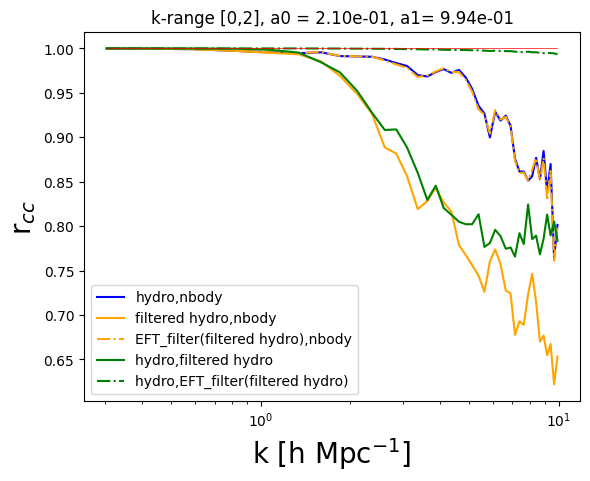


Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.01
Time taken = 0.01 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.01 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.01 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.01 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.01 seconds


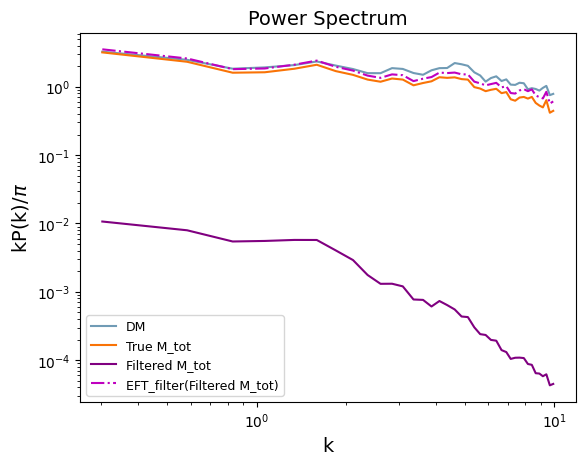

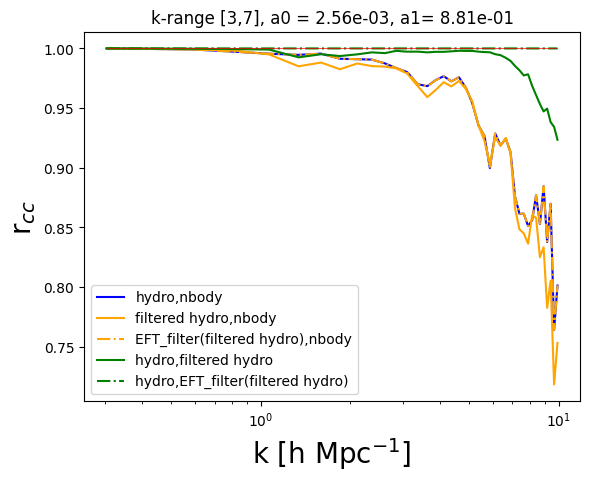


Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.01
Time taken = 0.01 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.01 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.01 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.01 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.01 seconds


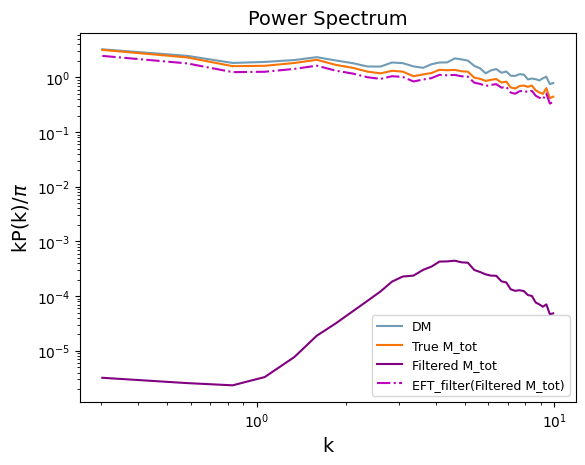

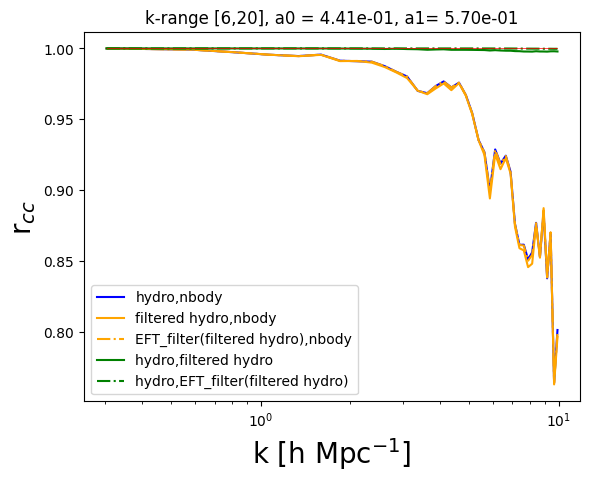


Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.01
Time taken = 0.01 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.01 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.01 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.01 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.01 seconds


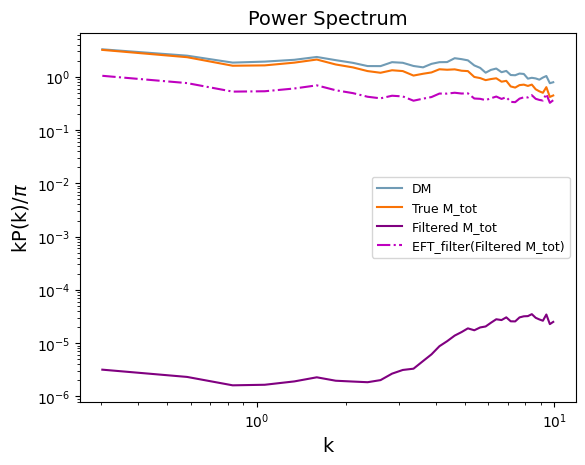

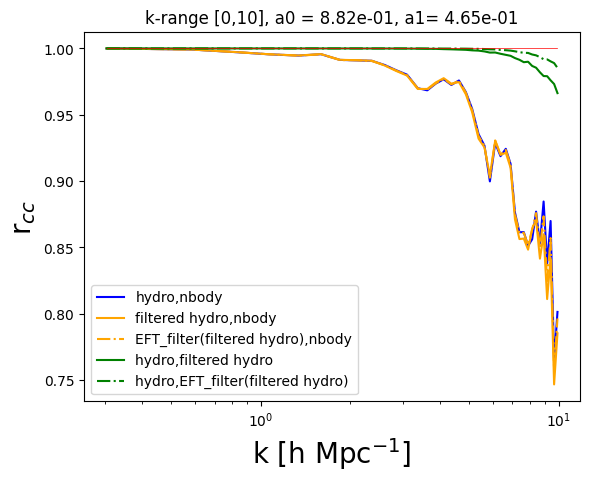

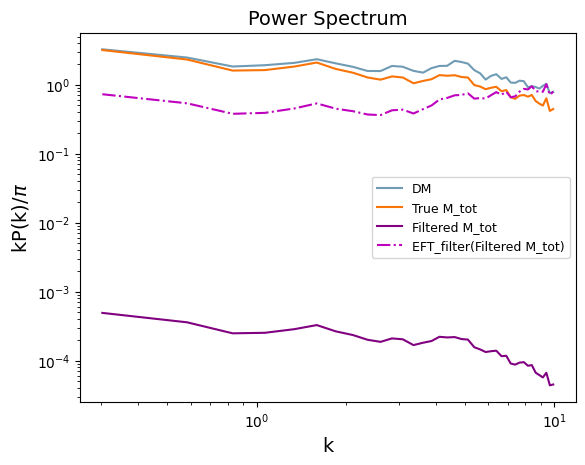

In [6]:
# Overdensity -- same Pk as physical units inverse transformation !!

grid    = 256     #the map will have grid^2 pixels
BoxSize = 25 #Mpc/h
MAS     = 'None'  #MAS used to create the image; 'NGP', 'CIC', 'TSC', 'PCS' o 'None'
threads = 1       #number of openmp threads
axis = 0
verbose = False

sims = [0,0,0,0]
low = [0,3,6,0]
high = [2,7,20,10]
for sim,l,h in zip(sims,low,high):
    filtered_x = fourier_filter(target[sim], l, h).cpu().numpy()
    #filtered_x = filtered_x/filtered_x.mean()-1
    eps,eps2 =torch.rand(2) #np.random.uniform()
    #x_filter_eft = EFTLSS(target[sim].detach().numpy().reshape([256,256]), filtered_x.reshape([256,256]), [eps, eps2])
    filtered_x_extra_terms = fourier_filter_EFT(target[sim], l, h, [eps, eps2]).cpu().numpy().reshape([256,256])

    plt.figure()
    Pkcc = PKL.XPk_plane((target[sim]).detach().numpy().reshape([256,256]),(cond[sim]).detach().numpy().reshape([256,256]),  BoxSize, MAS,MAS, threads=1) 
    kcc_true   = Pkcc.k
    Pk0_X_true = Pkcc.r
    plt.plot(kcc_true[kcc_true <= 10], Pk0_X_true[kcc_true <= 10],color ='b',label = f'hydro,nbody')
    Pkcc_ = PKL.XPk_plane(filtered_x.reshape([256,256]),(cond[sim]).detach().numpy().reshape([256,256]),  BoxSize, MAS,MAS, threads=1) 
    kcc_true_   = Pkcc_.k
    Pk0_X_true_ = Pkcc_.r
    plt.plot(kcc_true_[kcc_true <= 10], Pk0_X_true_[kcc_true <= 10],color ='orange',label = f'filtered hydro,nbody')
    #Pkcc_eft = PKL.XPk_plane(x_filter_eft.astype(np.float32).reshape([256,256]),(cond[sim]).detach().numpy().reshape([256,256]),  BoxSize, MAS,MAS, threads=1) 
    #kcc_true_eft   = Pkcc_eft.k
    #Pk0_X_true_eft = Pkcc_eft.r
    #plt.plot(kcc_true_eft[kcc_true <= 10], Pk0_X_true_eft[kcc_true <= 10],'--',color ='orange',label = f'EFT_FL(filtered hydro),nbody')
    Pkcc_eft = PKL.XPk_plane(filtered_x_extra_terms.astype(np.float32).reshape([256,256]),(cond[sim]).detach().numpy().reshape([256,256]),  BoxSize, MAS,MAS, threads=1) 
    kcc_true_eft   = Pkcc_eft.k
    Pk0_X_true_eft = Pkcc_eft.r
    plt.plot(kcc_true_eft[kcc_true <= 10], Pk0_X_true_eft[kcc_true <= 10],'-.',color ='orange',label = f'EFT_filter(filtered hydro),nbody')
    
    Pkcc = PKL.XPk_plane((target[sim]).detach().numpy().reshape([256,256]),filtered_x.reshape([256,256]),  BoxSize, MAS,MAS, threads=1)     
    kcc_true   = Pkcc.k
    Pk0_X_true = Pkcc.r
    plt.plot(kcc_true[kcc_true <= 10], Pk0_X_true[kcc_true <= 10],color ='g',label = f'hydro,filtered hydro')
    #Pkcc = PKL.XPk_plane((target[sim]).detach().numpy().reshape([256,256]),x_filter_eft.astype(np.float32).reshape([256,256]),  BoxSize, MAS,MAS, threads=1) 
    #kcc_true   = Pkcc.k
    #Pk0_X_true = Pkcc.r
    #plt.plot(kcc_true[kcc_true <= 10], Pk0_X_true[kcc_true <= 10],'--',color ='g',label = f'hydro,EFT_FL(filtered hydro)')
    Pkcc = PKL.XPk_plane((target[sim]).detach().numpy().reshape([256,256]),filtered_x_extra_terms.astype(np.float32),  BoxSize, MAS,MAS, threads=1) 
    kcc_true   = Pkcc.k
    Pk0_X_true = Pkcc.r
    plt.plot(kcc_true[kcc_true <= 10], Pk0_X_true[kcc_true <= 10],'-.',color ='g',label = f'hydro,EFT_filter(filtered hydro)')
    plt.plot(kcc_true[kcc_true <= 10],np.ones_like(kcc_true[kcc_true <= 10]),color ='r',lw=0.5)
    plt.xscale('log')
    plt.xlabel(r'k [h Mpc$^{-1}$]', fontsize=20)
    plt.ylabel(r'r$_{cc}$', fontsize=20)
    plt.title(f'k-range [{l},{h}], a0 = {eps.numpy():.2e}, a1= {eps2.numpy():.2e}')
    plt.legend()
    plt.show()

    ## compute_pk == PKL!!
    plt.figure()
    k, P_con = compute_pk(cond[sim].cpu().numpy().reshape([1,1,256,256]))
    plt.loglog(k, k*P_con/np.pi, label="DM", color='#709bb5')
    k, P_x = compute_pk(target[sim].cpu().numpy().reshape([1,1,256,256]))
    plt.loglog(k, k*P_x/np.pi, label="True M_tot", color='#F97306')
    k, P_x_filter = compute_pk(filtered_x.reshape([1,1,256,256]))
    plt.loglog(k, k*P_x_filter/np.pi, label="Filtered M_tot", color='purple')
    kcc_idx = np.array([np.argmin(np.abs(kcc_true - ki)) for ki in k])
    #P_x_filter_eft = P_x_filter +2/(9*0.45037521)*k**2* P_x_filter
    #P_x_filter_eft = P_x_filter + eps*k**2* P_x_filter
    #plt.loglog(k, k*P_x_filter_eft/np.pi, label="Filtered M_tot + C", color='red')
    #P_x_filter_eft_ = P_x_filter_eft+P_x*(1-Pk0_X_true[kcc_idx]**2)
    #plt.loglog(k, k*P_x_filter_eft_/np.pi, '--', label="Filtered M_tot + C + P_J", color='red')
    #k, P_x_filter_eft = compute_pk(x_filter_eft.reshape([1,1,256,256]))
    #plt.loglog(k, k*P_x_filter_eft/np.pi, '--', label="EFT_FL(Filtered M_tot)", color='m')
    k, P_x_filter_eft_filter = compute_pk(filtered_x_extra_terms.reshape([1,1,256,256]))
    plt.loglog(k, k*P_x_filter_eft_filter/np.pi, '-.', label="EFT_filter(Filtered M_tot)", color='m')

   
    Pk2D_hydro = PKL.Pk_plane(target[sim].detach().numpy().reshape([256,256]), BoxSize, MAS, threads, verbose)
    Pk2D_Nbody = PKL.Pk_plane(cond[sim].detach().numpy().reshape([256,256]), BoxSize,  MAS, threads, verbose)
    k   = Pk2D_Nbody.k
    P_con   = Pk2D_Nbody.Pk
    #plt.loglog(k[k<10], P_con[k<10], label="DM PKL", color='#709bb5', ls = '--')
    k   = Pk2D_hydro.k
    P_x   = Pk2D_hydro.Pk
    #plt.loglog(k[k<10], P_x[k<10], label="True M_tot PKL", color='#F97306', ls = '--')
    plt.legend(fontsize=9)
    plt.title(f'k-range [{l},{h}]')
    plt.xlabel('k',fontsize=14)
    plt.ylabel('kP(k)/$\pi$',fontsize=14)
    plt.title("Power Spectrum", fontsize=14)

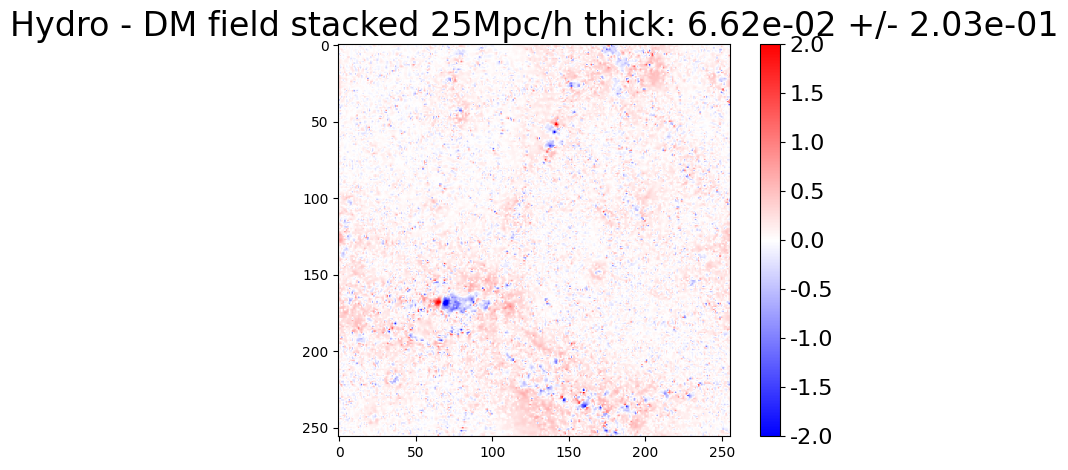

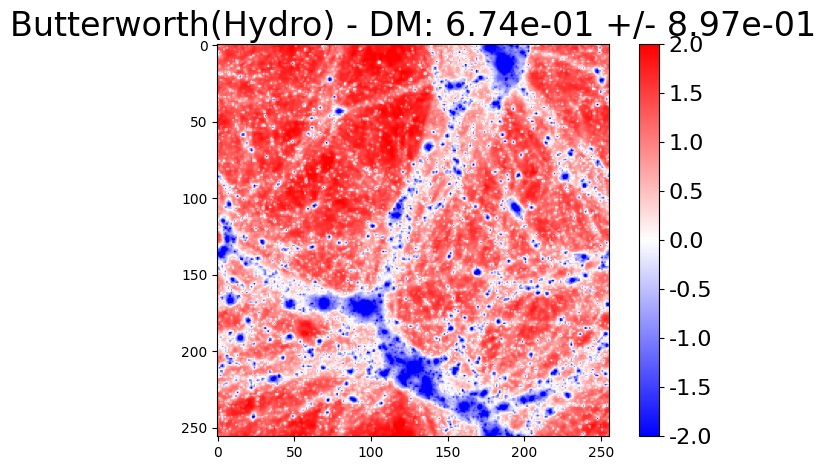

/tmp/ipykernel_1450648/727449289.py:35: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  diff_trans_eft =  np.log(fourier_filter_EFT(target[0], l,h, [eps1, 1]).reshape([256,256])+1) -  np.log(NBody_map+1)


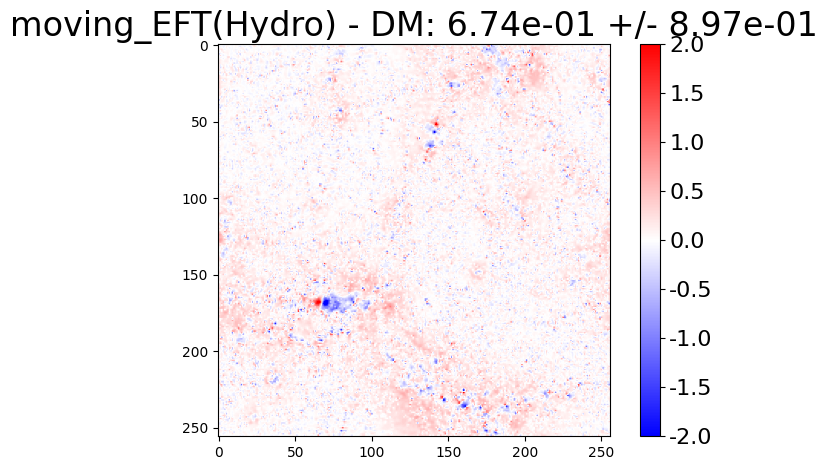

In [40]:
## import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import FormatStrFormatter
colors = [(0, 'blue'), (0.5, 'white'), (1, 'red')]
cmap = LinearSegmentedColormap.from_list('custom', colors)

vmin = -2.0
vmax = 2.0
l=6
h=20

filteredx = fourier_filter(target[0], l, h).cpu().numpy().reshape([256,256])

hydro_map = target[0].squeeze(0).numpy()
NBody_map = cond[0].squeeze(0).numpy()
diff = np.log(hydro_map+1) - np.log(NBody_map+1)
plt.figure()
im = plt.imshow(diff, cmap=cmap, vmin=vmin, vmax=vmax)
cbar = plt.colorbar(im, format=FormatStrFormatter('%.1f'))
cbar.ax.tick_params(labelsize=16)
plt.title(f'Hydro - DM field stacked 25Mpc/h thick: {diff.mean():.2e} +/- {diff.std():.2e}', fontsize=24)
plt.tight_layout()
plt.show()

plt.figure()
diff_trans = np.log(filteredx+1) -  np.log(NBody_map+1)
im = plt.imshow(diff_trans, cmap=cmap, vmin=vmin, vmax=vmax)
cbar = plt.colorbar(im, format=FormatStrFormatter('%.1f'))
cbar.ax.tick_params(labelsize=16)
plt.title(f'Butterworth(Hydro) - DM: {diff_trans.mean():.2e} +/- {diff_trans.std():.2e}', fontsize=24)
plt.tight_layout()
plt.show()

plt.figure()
diff_trans_eft =  np.log(fourier_filter_EFT(target[0], l,h, [eps1, 1]).reshape([256,256])+1) -  np.log(NBody_map+1) 
im = plt.imshow(diff_trans_eft, cmap=cmap, vmin=vmin, vmax=vmax)
cbar = plt.colorbar(im, format=FormatStrFormatter('%.1f'))
cbar.ax.tick_params(labelsize=16)
plt.title(f'moving_EFT(Hydro) - DM: {diff_trans.mean():.2e} +/- {diff_trans.std():.2e}', fontsize=24)
plt.tight_layout()
plt.show()

In [50]:
from scipy.stats import chisquare, norm
from scipy.optimize import minimize, curve_fit
from torch import Tensor

def chi2(a):
    return np.mean((fourier_filter_EFT(Tensor(hydro_map).unsqueeze(0), 6,20, a).numpy()-hydro_map)**2)
    
res = minimize(chi2,x0=[0.1,1],method="Powell")
a_sol_1, a_sol_2 = res.x

In [51]:
print(a_sol_1, a_sol_2) #-(2/9*c^2/H^2)^0.5 = -0.006734350297

-0.0013944775037358997 0.9979006653181419


k-range [0,2], a0 = 8.81e-03


/tmp/ipykernel_1450648/3426255352.py:8: RuntimeWarning: invalid value encountered in log
  diff_trans_eft =  np.log(filtered_x_extra_terms+1) -  np.log(NBody_map+1)


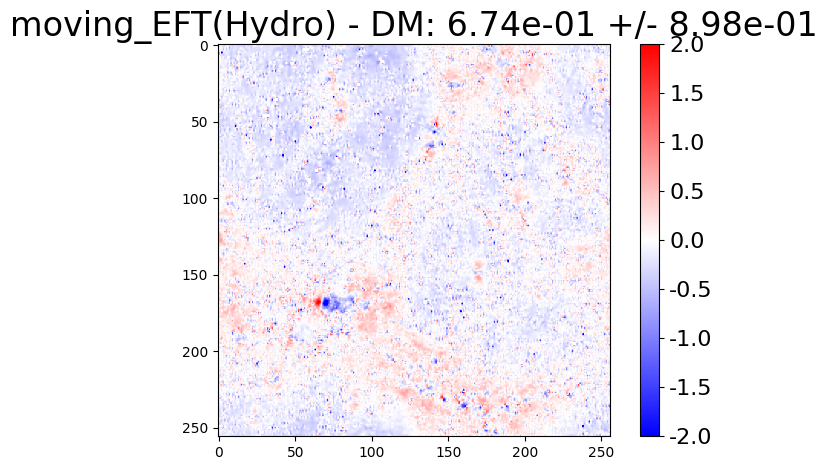


Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.01 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.01 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.01 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.01 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.01 seconds


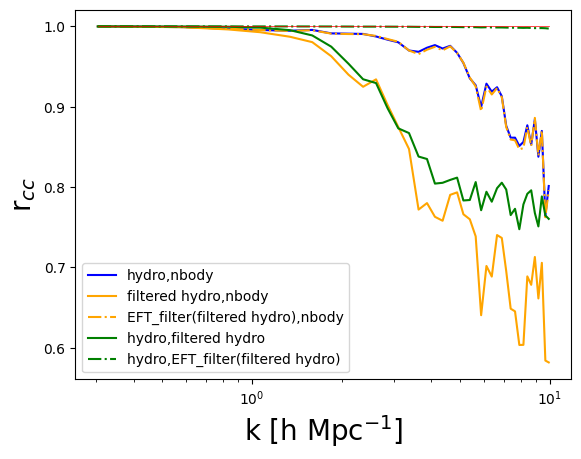

k-range [3,7], a0 = 8.81e-03


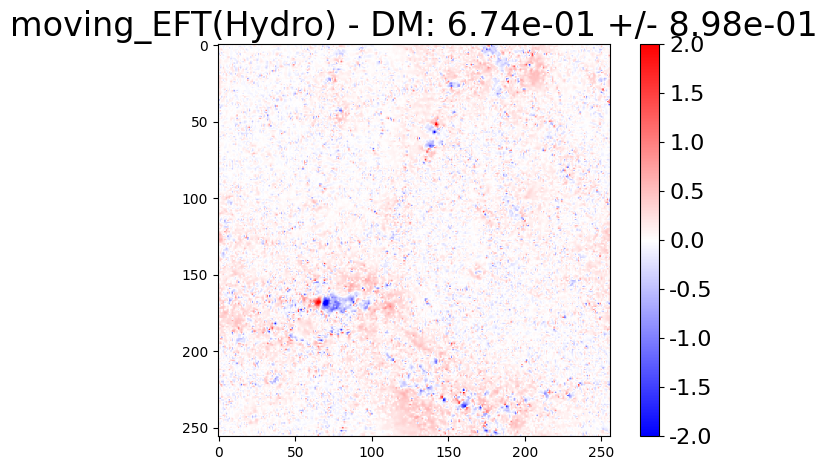


Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.01 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.01 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.01 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.01 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.01 seconds


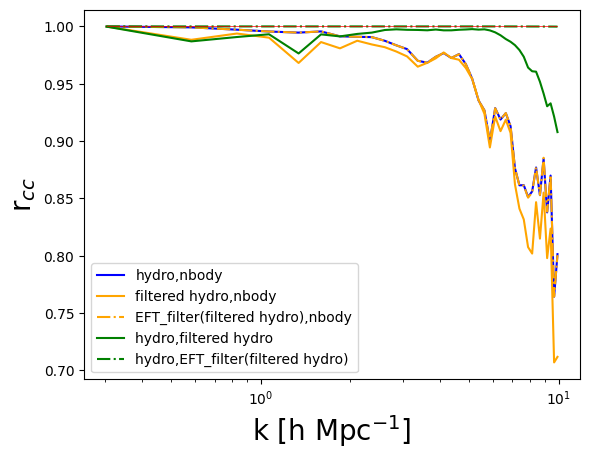

k-range [6,20], a0 = 8.81e-03


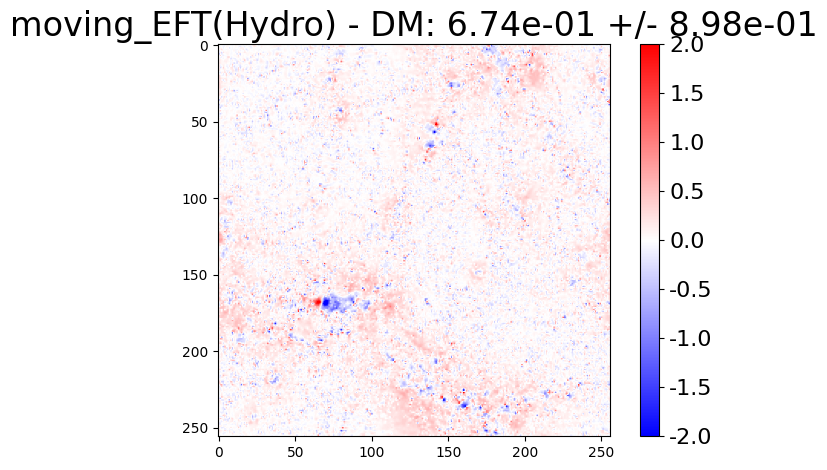


Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.01
Time taken = 0.01 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.01 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.01 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.01 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.01 seconds


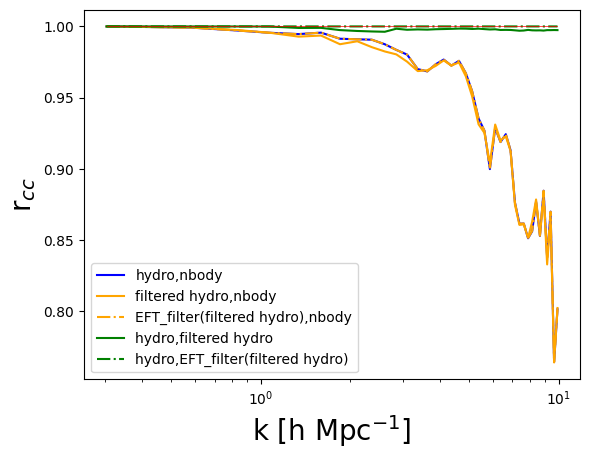

k-range [3,10], a0 = 8.81e-03


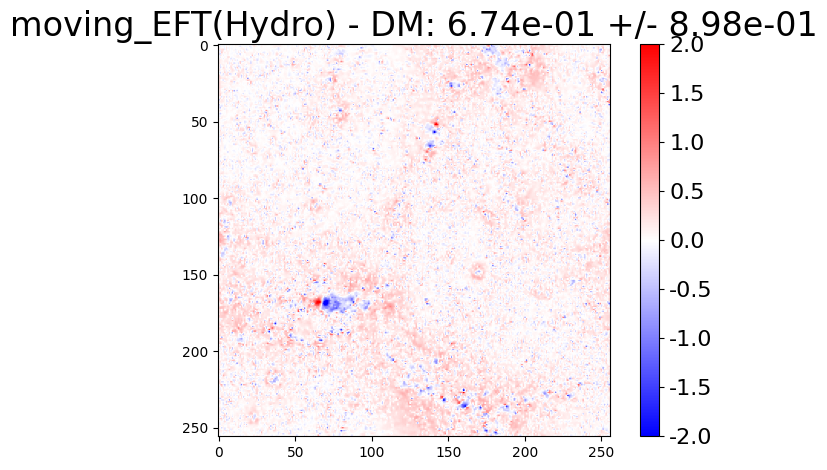


Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.01 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.01 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.01 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.01 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.01 seconds


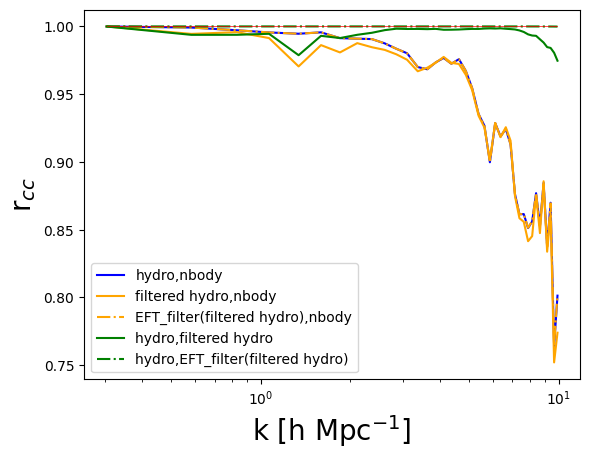

best a0: -0.0007882412476492724, a1: 0.9942674039558059 for 3-10 h/Mpc
best a0: -0.0013944775037358997, a1: 0.9979006653181419 for 6-20 h/Mpc


/tmp/ipykernel_1450648/3426255352.py:49: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  diff_trans_eft =  np.log(fourier_filter_EFT(target[0], l,h, [-0.0007882412476492724,0.9979006653181419]).reshape([256,256])+1) -  np.log(NBody_map+1)


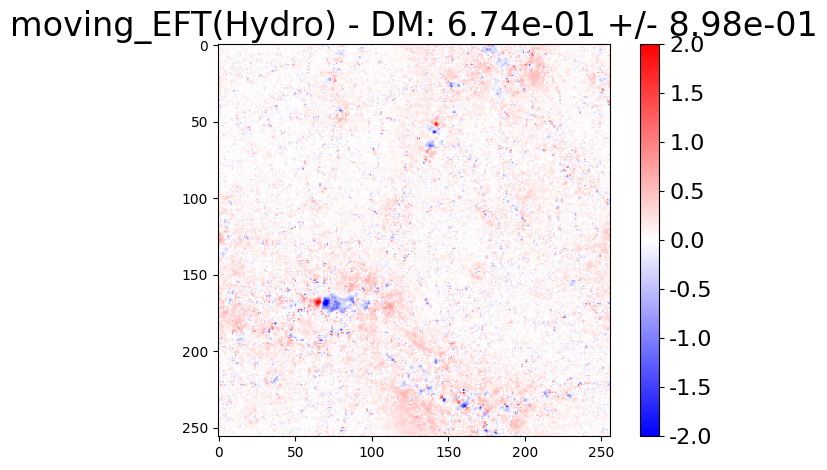

In [35]:
sim = 0
low = [0,3,6,3]
high = [2,7,20,10]
for l,h in zip(low,high):
    a0,a1 = torch.randn(1)*0.1, 1
    print(f'k-range [{l},{h}], a0 = {eps.numpy()[0]:.2e}')
    filtered_x_extra_terms = fourier_filter_EFT(target[0], l,h, [a0,a1]).numpy().reshape([256,256])
    diff_trans_eft =  np.log(filtered_x_extra_terms+1) -  np.log(NBody_map+1) 
    im = plt.imshow(diff_trans_eft, cmap=cmap, vmin=vmin, vmax=vmax)
    cbar = plt.colorbar(im, format=FormatStrFormatter('%.1f'))
    cbar.ax.tick_params(labelsize=16)
    plt.title(f'moving_EFT(Hydro) - DM: {diff_trans.mean():.2e} +/- {diff_trans.std():.2e}', fontsize=24)
    plt.tight_layout()
    plt.show()

    filtered_x = fourier_filter(target[sim], l, h).cpu().numpy()

    plt.figure()
    Pkcc = PKL.XPk_plane((target[sim]).detach().numpy().reshape([256,256]),(cond[sim]).detach().numpy().reshape([256,256]),  BoxSize, MAS,MAS, threads=1) 
    kcc_true   = Pkcc.k
    Pk0_X_true = Pkcc.r
    plt.plot(kcc_true[kcc_true <= 10], Pk0_X_true[kcc_true <= 10],color ='b',label = f'hydro,nbody')
    Pkcc_ = PKL.XPk_plane(filtered_x.reshape([256,256]),(cond[sim]).detach().numpy().reshape([256,256]),  BoxSize, MAS,MAS, threads=1) 
    kcc_true_   = Pkcc_.k
    Pk0_X_true_ = Pkcc_.r
    plt.plot(kcc_true_[kcc_true <= 10], Pk0_X_true_[kcc_true <= 10],color ='orange',label = f'filtered hydro,nbody')

    Pkcc_eft = PKL.XPk_plane(filtered_x_extra_terms.reshape([256,256]),(cond[sim]).detach().numpy().reshape([256,256]),  BoxSize, MAS,MAS, threads=1) 
    kcc_true_eft   = Pkcc_eft.k
    Pk0_X_true_eft = Pkcc_eft.r
    plt.plot(kcc_true_eft[kcc_true <= 10], Pk0_X_true_eft[kcc_true <= 10],'-.',color ='orange',label = f'EFT_filter(filtered hydro),nbody')
    Pkcc = PKL.XPk_plane((target[sim]).detach().numpy().reshape([256,256]),filtered_x.reshape([256,256]),  BoxSize, MAS,MAS, threads=1)     
    kcc_true   = Pkcc.k
    Pk0_X_true = Pkcc.r
    plt.plot(kcc_true[kcc_true <= 10], Pk0_X_true[kcc_true <= 10],color ='g',label = f'hydro,filtered hydro')
    Pkcc = PKL.XPk_plane((target[sim]).detach().numpy().reshape([256,256]),filtered_x_extra_terms.astype(np.float32),  BoxSize, MAS,MAS, threads=1) 
    kcc_true   = Pkcc.k
    Pk0_X_true = Pkcc.r
    plt.plot(kcc_true[kcc_true <= 10], Pk0_X_true[kcc_true <= 10],'-.',color ='g',label = f'hydro,EFT_filter(filtered hydro)')
    plt.plot(kcc_true[kcc_true <= 10],np.ones_like(kcc_true[kcc_true <= 10]),color ='r',lw=0.5)
    plt.xscale('log')
    plt.xlabel(r'k [h Mpc$^{-1}$]', fontsize=20)
    plt.ylabel(r'r$_{cc}$', fontsize=20)
    plt.legend()
    plt.show()
    
print(f'best a0: {-0.0007882412476492724}, a1: {0.9942674039558059} for 3-10 h/Mpc')
print(f'best a0: {-0.0013944775037358997}, a1: {0.9979006653181419} for 6-20 h/Mpc')
diff_trans_eft =  np.log(fourier_filter_EFT(target[0], l,h, [-0.0007882412476492724,0.9979006653181419]).reshape([256,256])+1) -  np.log(NBody_map+1) 
im = plt.imshow(diff_trans_eft, cmap=cmap, vmin=vmin, vmax=vmax)
cbar = plt.colorbar(im, format=FormatStrFormatter('%.1f'))
cbar.ax.tick_params(labelsize=16)
plt.title(f'moving_EFT(Hydro) - DM: {diff_trans.mean():.2e} +/- {diff_trans.std():.2e}', fontsize=24)
plt.tight_layout()
plt.show()